Deposit market clearing: 0.9927516024910438


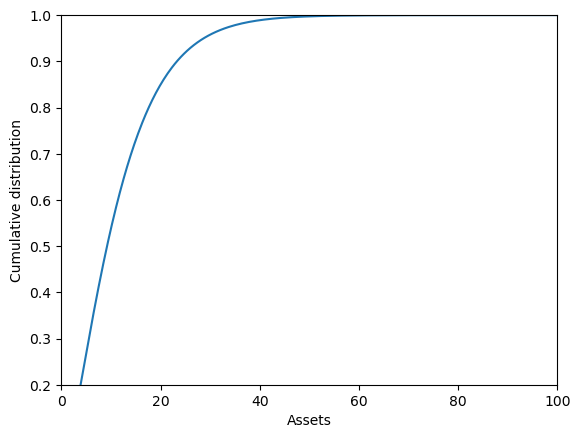

{'frisch': 1.0, 'eis': 0.5, 'habit': 0.0, 'C_lag': 0.0, 'rdep': 0.0065, 'rb': 0.0065, 'B_supply': 2.4, 'T': 0.15, 'b_gov': 2.4, 'b_gov_ss': 2.4, 'tau': 0.181, 'lamb': 0.85, 'lamb_ss': 0.85, 'phi_lamb': 0.05, 'Y': 1.0, 'N': 1.0, 'w': 0.65, 'f': 0.06, 'lambda_gk': 0.116, 'ksi': 0.5, 'n_inter': 3.0, 'theta': 4, 'alpha': 0.35, 'delta': 0.0125, 'nZ': 19, 'nDep': 500, 'Depmax': 150, 'rho_z': 0.9, 'sigma_z': 0.5, 'Q': 1.0, 'pi_w': 0.0, 'pi': 0.0, 'epsilon_w': 6.0, 'theta_w': 100.0, 'beta': 0.9927516024910438, 'K': 12.0, 'rk': 0.016666666666666663, 'rn': 0.047166666666666655, 'm': 0.04699000000000042, 'k_inter': 12.0, 'I': 0.15000000000000002, 'D_supply': 11.4, 'Z': 0.4190699921000142, 'rdep_ante': 0.0065, 'phi_b': 0.7999999999999999, 'div': 0.14149999999999996, 'iota': 0.0125, 'mpk': 0.029166666666666664, 'Omega': 0.4463356479296318, 'nu': 0.0045048543689320385, 'eta': 0.4459805825242719, 'gamma0': 0.22360679774997896, 'gamma1': -0.0125, 'DEP': np.float64(11.40000000440548), 'C': np.float64(0

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import sequence_jacobian as sj
from sequence_jacobian import simple, solved, combine, create_model
from sequence_jacobian import grids, hetblocks

from pathlib import Path
import numpy as np
import scipy.linalg
import os

from pathlib import Path
import numpy as np
import scipy.linalg
from sequence_jacobian import grids

# 1. Robust Path Definition
try:
    # Works if running as a .py script
    BASE_DIR = Path(__file__).resolve().parent
except NameError:
    # Works if running in a Jupyter Notebook
    BASE_DIR = Path.cwd()

# REMOVE .parent here. 
# Your image shows 'Discretisation' is in the same folder as the notebook.
DATA_DIR = BASE_DIR / "Discretisation" / "Outputs"


calibration_start = {

    #==> Household parameters (single deposit asset) efe
    'frisch': 1.0,    # Frisch elasticity of labour supply (1/varphi)
    'eis': 0.5,       # Intertemporal elasticity of substitution (1/sigma)
    'habit': 0.00,    # Habit formation parameter (h)
    'C_lag': 0.0,     # Previous Consumption

    #==> Deposit rate 
    'rdep': 0.0065,

    #==> Bond rate
    'rb': 0.0065,

    #==> Government bonds
    'B_supply': 0.6*4,

    #==> Policy parameters
    'T': 0.15,         # Linear tax on labour income
    'b_gov':   0.6*4,    # = B_supply
    'b_gov_ss': 0.6*4,   # SS anchor used in tax rule

    'tau': 0.181,       # Progressivity parameter (US estimate)
    'lamb': 0.85,       # Level parameter (~15% average tax rate)
    'lamb_ss': 0.85,    # SS anchor for the fiscal rule
    'phi_lamb': 0.05,   # Fiscal adjustment rule (adjusts lambda)

    ##==> Aggregate targets
    'Y':  1.00,
    'N':  1.00,
    'w':  0.70,

    ##==> Financial intermediary
    'f': 0.06,
    'lambda_gk': 0.116,
    'ksi': 0.5,                  # Capital adjustment cost
    'n_inter': 0.75*4,             # Financial intermediary net worth
    'theta':   4,                # Capital leverage (k_inter / n_inter)

    #==> Production
    'alpha': 0.35,               # Capital share in production
    'delta': 0.0125,             # Depreciation rate (quarterly)

    #==> Deposit grid (single asset)
    'nZ': 19,                       # Matrix loads with 19 Number of income states
    'nDep': 500,                    # Number of deposit grid points
    'Depmax': 150,                 # Maximum deposits

    #==> Not used unless nZ != 19
    'rho_z': 0.9,
    'sigma_z': 0.5,

    #==> Tobin's q (= 1 in steady state with standard adjustment cost calibration)
    'Q': 1.0,

    #==> Wage and Price Rigidity Parameters
    'pi_w': 0.0,         # Steady-state wage inflation
    'pi': 0.0,           # Steady-state price inflation
    'epsilon_w': 6.0,    # Elasticity of substitution for labor
    'theta_w': 100.0,    # Rotemberg wage adjustment cost parameter

}

calibration_hh = {
    **calibration_start,

    #==> Calibrated so deposit market clears
    'beta': 0.9927516024910438,

    #==> Dividend income (bank equity return to HH) in steady state
    'div': 0.20,
}



# 1. Initialize Household
def hh_init(dep_grid, z, rdep, eis):
    coh = (1 + rdep) * dep_grid[np.newaxis, :] + z[:, np.newaxis]
    Vdep = (1 + rdep) * coh ** (-1 / eis)
    return Vdep

# 2. Backward Step (HH Block)
@sj.het(exogenous='Pi', policy='dep', backward='Vdep', backward_init=hh_init)
def hh(Vdep_p, dep_grid, z, t_paid, rdep, beta, eis):
    uc_nextgrid = beta * Vdep_p
    c_nextgrid = uc_nextgrid ** (-eis)
    coh = (1 + rdep) * dep_grid[np.newaxis, :] + z[:, np.newaxis]
    
    dep = sj.interpolate.interpolate_y(c_nextgrid + dep_grid, coh, dep_grid)
    sj.misc.setmin(dep, dep_grid[0])
    
    c = coh - dep
    uce = c ** (-1 / eis)        
    Vdep = (1 + rdep) * uce
    
    # Broadcast individual tax paid to the full state-space grid
    # sequence_jacobian will automatically integrate this into aggregate 'TAX'
    tax = t_paid[:, np.newaxis] + np.zeros_like(dep_grid[np.newaxis, :])
    
    return Vdep, dep, c, uce, tax

# 3. Grids and Income
def make_grids(Depmax, nDep, nZ, rho_z, sigma_z):
    """Single-asset (deposit) grid — no illiquid or capital grid."""
    dep_grid = grids.agrid(amax=Depmax, n=nDep)

    if nZ == 19:
        # Construct paths safely
        px_path = DATA_DIR / "Px_GMAR.txt"
        x_path = DATA_DIR / "x_vec.txt"
        e_grid = np.loadtxt(x_path).flatten()       
        Pi = np.loadtxt(px_path)
        row_sums = Pi.sum(axis=1)
        Pi = Pi / row_sums[:, None]  # normalize for any floating-point drift
        Pi[:, -1] = 1.0 - Pi[:, :-1].sum(axis=1)

    else:
        e_grid, _, Pi = grids.markov_rouwenhorst(rho=rho_z, sigma=sigma_z, N=nZ)

    return dep_grid, e_grid, Pi




def income(e_grid, w, N, div, tau, lamb):
    # Endogenous labor: wages are multiplied by hours worked (N)
    y_pre = w * N * e_grid + div
    z = lamb * (y_pre ** (1 - tau))
    t_paid = y_pre - z
    return z, t_paid

hh_extended = hh.add_hetinputs([make_grids, income])

# 4. Steady State & Market Blocks

@simple
def smart_steady(theta, Y, n_inter, rdep, alpha, delta, f, N, B_supply, rb):
    K        = theta * n_inter
    phi_b    = B_supply / n_inter
    rk       = alpha * Y / K - delta
    rn       = theta * (rk - rdep) + phi_b * (rb - rdep) + rdep
    m        = n_inter * (1 - (1 - f) * (1 + rn))
    k_inter  = K
    I        = K * delta
    D_supply = (theta - 1) * n_inter + B_supply
    Z        = Y / ((K ** alpha) * (N ** (1 - alpha)))
    rdep_ante = rdep
    return K, rk, rn, m, k_inter, I, D_supply, Z, rdep_ante, phi_b

@simple
def ss_wage_markup(w, UCE, N, frisch, epsilon_w):
    # Calculates the labor disutility weight 'chi' to make the SS steady
    # Target condition: w = (epsilon_w / (epsilon_w - 1)) * mrs
    mrs_target = w * (epsilon_w - 1) / epsilon_w
    
    # Since mrs = chi * N**(1/frisch) / UCE, we solve for chi:
    chi = mrs_target * UCE / (N ** (1 / frisch))
    return chi

@simple
def market_clearing(Y, C, I, G, DEP,D_supply, pi_w, theta_w):
    adj_costs_w = (theta_w / 2) * (pi_w ** 2) * Y
    goods_mkt = Y - C - I - G  - adj_costs_w
    
    deposit_mkt = DEP - D_supply
    return goods_mkt, deposit_mkt

@simple
def steady_auxilliary(theta, rk, rdep, rb, delta, alpha, Y, K, N, lambda_gk, beta, ksi, rn, phi_b):
    iota   = delta
    mpk    = alpha * (Y / K)
    w      = (1 - alpha) * Y / N
    Omega = theta * lambda_gk / (beta * ((1+rn) - phi_b*(rb - rdep)))
    nu     = beta * Omega * (rk - rdep)
    eta    = beta * Omega * (1 + rdep)
    gamma0 = delta ** ksi / (1 - ksi)
    gamma1 = -delta * ksi / (1 - ksi)
    return iota, mpk, w, Omega, nu, eta, gamma0, gamma1

@simple
def banker_div(rn, n_inter):
    div = rn * n_inter
    return div

@simple
def sdf(beta, UCE):
    SDF = beta * UCE(+1) / UCE
    return SDF

@simple
def government_ss(TAX, rb, B_supply):
    # G is the residual in steady state, funded by aggregate TAX
    G = TAX - rb * B_supply
    return G

@simple
def labor_supply(N, UCE, frisch, chi):
    # Include the disutility scale 'chi'
    v_prime = chi * N ** (1 / frisch)
    mrs = v_prime / UCE
    return mrs

# 5. Create Model
ha = sj.create_model([
    hh_extended, 
    smart_steady, 
    government_ss, # <-- Add this here!
    market_clearing, 
    steady_auxilliary, 
    banker_div,
    ss_wage_markup, 
    labor_supply,      
    sdf
], name="Simple HA Model")


# 6. Solve Steady State
# Ensure calibration_start contains all required inputs (theta, Y, n_inter, etc.)
unknowns_ss = {'beta': (0.97,0.993)} 
targets_ss  = ['deposit_mkt']

solver_options = {
    'hh': {
        'forward_maxit': 200000, # Increase max iterations (Default: 100000)
        'forward_tol': 1e-10      # Loosen tolerance slightly (Default: 1e-10)
    }
}

ss = ha.solve_steady_state(
    calibration_start, 
    unknowns_ss, 
    targets_ss, 
    solver='bisect',
    options=solver_options   
)
print(f"Deposit market clearing: {ss['beta']}")

D = ss.internals['hh']['D'].sum(axis=0)
dep_grid = ss.internals['hh']['dep_grid']
plt.plot(dep_grid, D.cumsum())
plt.ylim([0.2, 1])
plt.xlim([0, 100])
plt.xlabel('Assets')
plt.ylabel('Cumulative distribution')
plt.show()


cali = ss
calibration = dict(ss)






# ── Off-Steady-State Equations ────────────────────────────────────────────────
@simple
def capital_adj(Y, K, Q, I, alpha, delta, gamma0, gamma1, ksi, Z):
    iota        = I / K(-1)
    mpk         = alpha * Y / K(-1)
    rk          = (mpk + (1 - delta) * Q) / Q(-1) - 1
    q_res       = Q - 1 / (gamma0 * (1 - ksi) * iota ** (-ksi)) +0*Z
    capital_res = K - (1 - delta) * K(-1) - (gamma0 * iota ** (1 - ksi) + gamma1) * K(-1) +0*Z
    return iota, mpk, rk, q_res, capital_res




@simple
def wage_pricing(pi_w, w, N, mrs, beta, epsilon_w, theta_w):
    # Exact non-linear Rotemberg Wage Phillips Curve
    # The term w * (epsilon_w - 1) / epsilon_w is the target real wage
    lhs = theta_w * pi_w * (1 + pi_w)
    rhs = beta * theta_w * pi_w(+1) * (1 + pi_w(+1)) + epsilon_w * N * (mrs - w * (epsilon_w - 1) / epsilon_w)
    
    pi_w_res = lhs - rhs
    return pi_w_res

@simple
def real_wage_evolution(pi_w, pi, w):
    # This block was already perfect in your code!
    w_res = (1 + pi_w) - (w / w(-1)) * (1 + pi)
    return w_res

@simple
def intermediation_IC(nu, eta, lambda_gk):
    theta = eta / (lambda_gk - nu)
    return theta


@simple
def bank_return(theta, rk, rdep, b_gov, n_inter, rb):
    # phi_b is predetermined (lagged balance-sheet ratio)
    phi_b_lag = b_gov(-1) / n_inter(-1)
    rn = theta(-1) * (rk - rdep) + phi_b_lag * (rb - rdep) + rdep
    return rn


@simple
def intermediation_P1(rk, rdep, nu, lambda_gk, eta, theta, SDF, f):
    # Bellman equations: bankers fund at deposit rate rd
    Omega_p1 = f + (1 - f) * lambda_gk * theta(+1)
    nu_res   = nu  - SDF * Omega_p1 * (rk(+1) - rdep(+1))
    eta_res  = eta - SDF * Omega_p1 * (1 + rdep(+1))
    return nu_res, eta_res

# K = theta * n_inter is the bank balance-sheet identity.
# Keeping it separate (not inside intermediation_P1) lets K be an outer unknown
# so capital_adj can use K without creating a cycle with intermediation_ne_solved.
@simple
def k_balance_sheet(theta, n_inter, K):
    K_res = K - theta * n_inter
    return K_res


@simple
def intermediation_P2(rn, n_inter, m, f):
    n_inter_val = (1 - f) * (1 + rn) * n_inter(-1) + m - n_inter
    return n_inter_val


@simple
def intermediation_P3(theta, n_inter, b_gov):
    D_supply = (theta - 1) * n_inter + b_gov
    return D_supply

@simple
def tax_rule(b_gov, lamb_ss, b_gov_ss, phi_lamb):
    # Note the minus sign: If debt is too high, lower lambda to raise taxes
    lamb = lamb_ss - phi_lamb * (b_gov(-1) - b_gov_ss)
    return lamb


@simple
def budget_residual(b_gov, G, TAX, rb):
    b_gov_res = (1 + rb) * b_gov(-1) + G - TAX - b_gov
    return b_gov_res


@simple
def rk_from_production(Y, K, alpha, delta):
    # rk at t uses capital chosen at t-1 (standard timing)
    rk = alpha * Y / K(-1) - delta
    return rk


@simple
def labor(Y, Z, K, alpha):
    # N adjusts to meet demand Y
    N = (Y / (Z * K(-1) ** alpha)) ** (1 / (1 - alpha))
    w = (1 - alpha) * Y / N
    return N, w



print(calibration)


In [39]:


@simple
def banker_div_res(rn, n_inter, div):
    # This evaluates how wrong the outer solver's guess for 'div' is
    div_res = div - rn * n_inter
    return div_res


# We only solve for the forward-looking variables internally
financial_solved = combine([
    intermediation_IC,
    intermediation_P1,
]).solved(
    unknowns={
        'nu':  float(cali['nu']),
        'eta': float(cali['eta']),
    },
    targets=['nu_res', 'eta_res'],
    solver='broyden_custom'
)

print("financial_solved inputs: ", financial_solved.inputs)
print("financial_solved outputs:", financial_solved.outputs)



ha_full = sj.create_model([
    hh_extended,
    financial_solved,
    bank_return,
    intermediation_P2,
    intermediation_P3,
    k_balance_sheet,
    capital_adj,
    sdf,
    tax_rule,
    budget_residual,
    labor,
    labor_supply,         # <- MISSING
    wage_pricing,         # <- MISSING
    real_wage_evolution,  # <- MISSING
    banker_div_res,
    market_clearing
], name="Full HANK Model")

#unknowns_tp = ['rdep', 'K', 'n_inter', 'div', 'I', 'Q', 'b_gov', 'Y', 'pi_w']
unknowns_tp = ['rdep', 'K', 'n_inter', 'div', 'I', 'Q', 'b_gov', 'Y', 'pi_w']

#targets_tp  = ['goods_mkt', 'K_res', 'n_inter_val', 'div_res', 'capital_res', 'q_res', 'b_gov_res', 'pi_w_res', 'w_res']
targets_tp  = ['goods_mkt', 'K_res', 'n_inter_val', 'div_res', 'capital_res', 'q_res', 'b_gov_res', 'pi_w_res', 'w_res']

T = 300 
exogenous = ['Z']

print(f"Computing Jacobian for horizon T={T}...")
G = ha_full.solve_jacobian(ss, unknowns_tp, targets_tp, exogenous, T=T)





financial_solved inputs:  ['lambda_gk', 'rk', 'rdep', 'SDF', 'f']
financial_solved outputs: ['theta', 'nu_res', 'eta_res', 'nu', 'eta']
Computing Jacobian for horizon T=300...


In [40]:
# 1. Compute the raw Jacobian (without trying to invert it)
H_U = ha_full.jacobian(ss, unknowns_tp, targets_tp, T=T)

# 2. Look at the block-diagonal structure
print(H_U)

<JacobianDict outputs=['goods_mkt', 'K_res', 'n_inter_val', 'div_res', 'capital_res', 'q_res', 'b_gov_res', 'pi_w_res', 'w_res'], inputs=['rdep', 'K', 'n_inter', 'div', 'I', 'Q', 'b_gov', 'Y', 'pi_w']>


In [41]:
# ── 4. Impulse Response Functions (TFP Shock) ───────────────────────
rho_Z = 0.9
dZ = 0.01 * rho_Z ** np.arange(T)
shocks = {'Z': dZ}

print("Computing linear impulse responses...")
irfs = ha_full.solve_impulse_linear(ss, unknowns_tp, targets_tp, shocks)


Computing linear impulse responses...


In [42]:
def show_irfs(irfs_list, variables, labels=[" "], ylabel=r"Percentage points (dev. from ss)", T_plot=40, figsize=(18, 6)):
    if len(irfs_list) != len(labels):
        labels = [" "] * len(irfs_list)
    n_var = len(variables)
    fig, ax = plt.subplots(1, n_var, figsize=figsize, sharex=True)
    for i in range(n_var):
        for j, irf in enumerate(irfs_list):
            ax[i].plot(irf[variables[i]][:T_plot], label=labels[j])
        ax[i].set_title(variables[i])
        ax[i].set_xlabel(r"$t$")
        if i == 0:
            ax[i].set_ylabel(ylabel)
        ax[i].legend()
    plt.show()

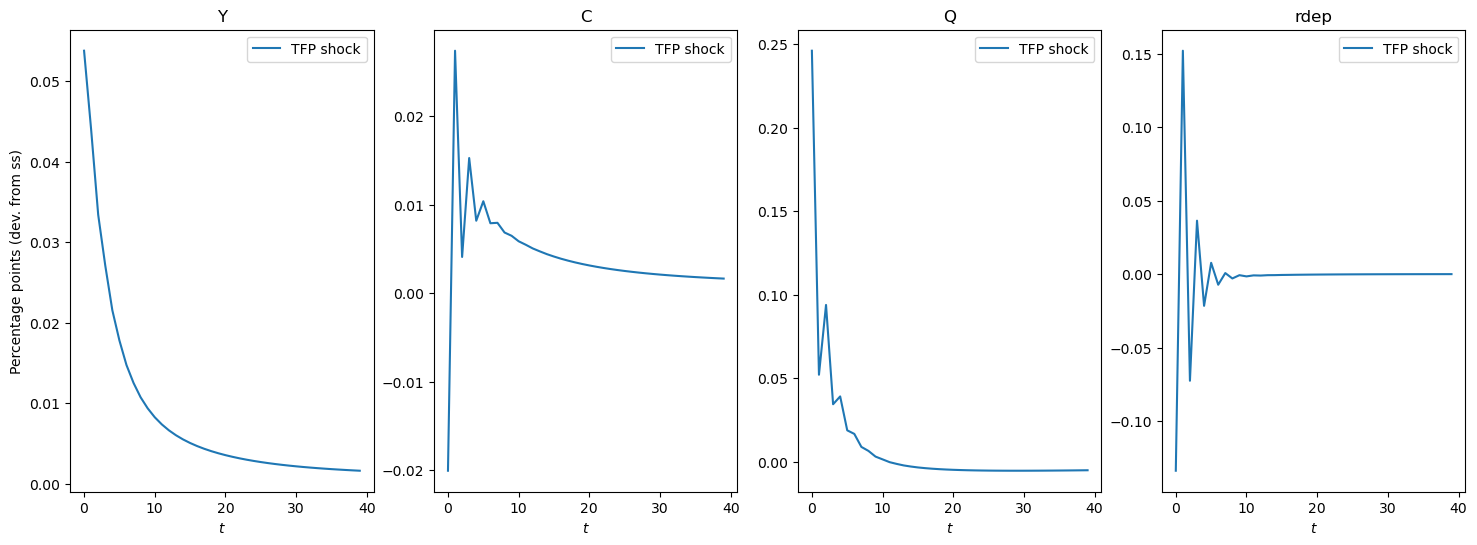

In [44]:
show_irfs([irfs], ['Y', 'C', 'Q', 'rdep'],
          labels=['TFP shock'])